# ❤️ Heart Murmur Detection — Full ML Pipeline
**Dataset:** CirCor DigiScope Phonocardiogram (PhysioNet)

This notebook covers:
1. Setup & Imports
2. Data Loading
3. Feature Extraction (MFCCs + Audio Stats)
4. Random Forest Model — Train, Evaluate, Save
5. Spectrogram Dataset Builder (for CNN)
6. CNN Model — Build, Train, Evaluate, Save

---
## 📦 1. Setup & Imports

In [1]:
!pip install librosa scikit-learn joblib tensorflow matplotlib seaborn pandas numpy scipy keras


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install --upgrade tensorflow keras


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy.stats import skew, kurtosis

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight


# Updated TensorFlow / Keras Imports
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import (
    Conv2D, MaxPooling2D, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D, Input
)
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.utils import to_categorical

print('✅ All libraries loaded successfully!')
print(f'TensorFlow version: {tf.__version__}')
print(f'Keras version: {keras.__version__}')


✅ All libraries loaded successfully!
TensorFlow version: 2.21.0
Keras version: 3.14.0


---
## ⚙️ 2. Configuration
**Update `DATASET_PATH` to your local path.**

In [4]:
# ── UPDATE THIS PATH ─────────────────────────────────────────────────────────
DATASET_PATH = r"C:\Users\Aditya\OneDrive\Desktop\final\data\the-circor-digiscope-phonocardiogram-1.0.3"

CSV_PATH   = os.path.join(DATASET_PATH, 'training_data.csv')
AUDIO_PATH = os.path.join(DATASET_PATH, 'training_data')

SR       = 22050          # Sample rate
N_MFCC   = 13             # Number of MFCCs
N_MELS   = 64             # Mel bands for spectrogram
MEL_TIME = 128            # Fixed time width for CNN input
REGIONS  = ['AV', 'MV', 'PV', 'TV']

# Sanity check
print('CSV exists    :', os.path.exists(CSV_PATH))
print('Audio folder  :', os.path.exists(AUDIO_PATH))
wav_files = [f for f in os.listdir(AUDIO_PATH) if f.endswith('.wav')]
print(f'WAV files found: {len(wav_files)}')

CSV exists    : True
Audio folder  : True
WAV files found: 3163


---
## 📂 3. Data Loading

In [5]:
def load_audio(filepath, sr=SR):
    """Load a .wav file and return numpy audio array."""
    try:
        audio, _ = librosa.load(filepath, sr=sr, mono=True)
        return audio
    except Exception:
        return None


def load_dataset(csv_path, audio_path, regions=REGIONS, limit=None):
    """
    Load the CirCor dataset.
    Returns a DataFrame with columns: Patient_ID, label, AV, MV, PV, TV.
    label = 1 if Murmur == 'Present' else 0.
    """
    annotations = pd.read_csv(csv_path)[['Patient ID', 'Murmur']]
    rows = []

    for idx, row in annotations.iterrows():
        patient_id = row['Patient ID']
        label = 1 if row['Murmur'] == 'Present' else 0

        sample = {'Patient_ID': patient_id, 'label': label}

        for region in regions:
            path = os.path.join(audio_path, f'{patient_id}_{region}.wav')
            sample[region] = load_audio(path) if os.path.exists(path) else None

        rows.append(sample)

        if limit and idx + 1 >= limit:
            break

    return pd.DataFrame(rows)


print('Loading dataset (this may take a minute)...')
df = load_dataset(CSV_PATH, AUDIO_PATH)
print(f'Dataset shape : {df.shape}')
print(f'Label distribution:\n{df["label"].value_counts()}')
df.head(3)

Loading dataset (this may take a minute)...
Dataset shape : (942, 6)
Label distribution:
label
0    763
1    179
Name: count, dtype: int64


,Patient_ID,label,AV,MV,PV,TV
0,2530,0,"[-0.010939252, -0.0074941535, -0.00054567493, ...","[0.35828927, 0.41234198, 0.4293147, 0.4129846,...","[0.07341617, 0.08361576, 0.08579627, 0.0809362...","[0.0648618, 0.07592062, 0.08099635, 0.0807517,..."
1,9979,1,"[0.0481489, 0.063403696, 0.07782403, 0.0908918...","[0.14412314, 0.17162335, 0.18714395, 0.1916133...","[0.9252373, 1.0759296, 1.1350776, 1.1097999, 1...","[0.011183679, 0.014192879, 0.011422738, -0.002..."
2,9983,0,"[0.026785327, 0.032267228, 0.035882264, 0.0379...","[-0.022333074, -0.026952397, -0.029604327, -0....","[0.09722612, 0.09432067, 0.07113489, 0.0300288...","[0.02446232, 0.027555577, 0.027927171, 0.02603..."


---
## 🔬 4. Feature Extraction (for Random Forest)

In [6]:
def extract_features(audio, sr=SR, n_mfcc=N_MFCC):
    """
    Extract handcrafted audio features:
      - RMS Energy, ZCR, Spectral Centroid, Bandwidth
      - Total Energy, Skewness, Kurtosis
      - 13 MFCCs (mean per coefficient)
    Returns a flat dict of feature_name → scalar value.
    """
    f = {}
    f['rms_mean']       = float(np.mean(librosa.feature.rms(y=audio)))
    f['zcr_mean']       = float(np.mean(librosa.feature.zero_crossing_rate(y=audio)))
    f['centroid_mean']  = float(np.mean(librosa.feature.spectral_centroid(y=audio, sr=sr)))
    f['bandwidth_mean'] = float(np.mean(librosa.feature.spectral_bandwidth(y=audio, sr=sr)))
    f['energy']         = float(np.sum(audio ** 2))
    f['skew']           = float(skew(audio))
    f['kurtosis']       = float(kurtosis(audio))

    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
    for i in range(n_mfcc):
        f[f'mfcc_{i+1}'] = float(np.mean(mfccs[i]))

    return f

In [8]:
print('Extracting features for all patients...')
feature_rows = []
skipped = 0

for _, row in df.iterrows():
    patient_features = {}

    for region in REGIONS:
        audio = row[region]
        if audio is None:
            continue
        try:
            feats = extract_features(audio)
            for k, v in feats.items():
                patient_features[f'{region}_{k}'] = v
        except Exception as e:
            print(f'  ⚠️  Error [{region}] patient {row["Patient_ID"]}: {e}')

    if not patient_features:
        skipped += 1
        continue

    patient_features['label'] = row['label']
    feature_rows.append(patient_features)

feature_df = pd.DataFrame(feature_rows).fillna(0)
print(f'Feature dataset shape : {feature_df.shape}')
print(f'Patients skipped      : {skipped}')

# Save to CSV
feature_df.to_csv('features1.csv', index=False)
print('✅ Features saved to features.csv')
feature_df.head(3)

Extracting features for all patients...
Feature dataset shape : (941, 81)
Patients skipped      : 1
✅ Features saved to features.csv


,AV_rms_mean,AV_zcr_mean,AV_centroid_mean,AV_bandwidth_mean,AV_energy,AV_skew,AV_kurtosis,AV_mfcc_1,AV_mfcc_2,AV_mfcc_3,...,TV_mfcc_5,TV_mfcc_6,TV_mfcc_7,TV_mfcc_8,TV_mfcc_9,TV_mfcc_10,TV_mfcc_11,TV_mfcc_12,TV_mfcc_13,label
0,0.044300,0.033030,498.478398,432.554634,4634.741211,0.052478,53.501193,-372.159790,175.397461,43.408947,...,-3.762542,23.391022,16.150452,-2.521557,1.387899,16.747282,15.634432,1.427426,-3.062017,0
1,0.079067,0.015019,342.306875,393.777211,3340.946045,-0.157955,13.311755,-353.741943,195.950714,49.825237,...,18.969809,39.720932,29.525873,6.334449,2.616046,13.341783,13.982291,2.858542,-2.268852,1
2,0.033871,0.027935,406.339682,346.519679,963.885315,0.350284,44.618655,-433.632690,229.031036,67.438377,...,-2.433071,29.987013,12.893270,-15.266092,-9.180028,11.474444,10.105393,-4.716592,-4.749847,0


---
## 🌲 5. Random Forest Model

In [9]:
# ── Load feature CSV (skip if already in memory) ─────────────────────────────
feature_df = pd.read_csv('features1.csv')

X = feature_df.drop('label', axis=1)
y = feature_df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Train size : {X_train.shape[0]}')
print(f'Test size  : {X_test.shape[0]}')

Train size : 752
Test size  : 189


In [10]:
# ── Build & train pipeline ────────────────────────────────────────────────────
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

print('Training Random Forest...')
rf_pipeline.fit(X_train, y_train)
print('✅ Training complete!')

Training Random Forest...
✅ Training complete!


In [11]:
# ── Evaluate at adjusted threshold ───────────────────────────────────────────
THRESHOLD = 0.3

probs_rf = rf_pipeline.predict_proba(X_test)[:, 1]
preds_rf = (probs_rf >= THRESHOLD).astype(int)

acc_rf  = accuracy_score(y_test, preds_rf)
auc_rf  = roc_auc_score(y_test, probs_rf)

print('=' * 50)
print(f'Random Forest  (threshold = {THRESHOLD})')
print('=' * 50)
print(f'Accuracy  : {acc_rf:.4f}')
print(f'ROC-AUC   : {auc_rf:.4f}')
print()
print(classification_report(y_test, preds_rf, target_names=['No Murmur', 'Murmur']))

Random Forest  (threshold = 0.3)
Accuracy  : 0.8466
ROC-AUC   : 0.7302

              precision    recall  f1-score   support

   No Murmur       0.88      0.94      0.91       153
      Murmur       0.64      0.44      0.52        36

    accuracy                           0.85       189
   macro avg       0.76      0.69      0.72       189
weighted avg       0.83      0.85      0.84       189



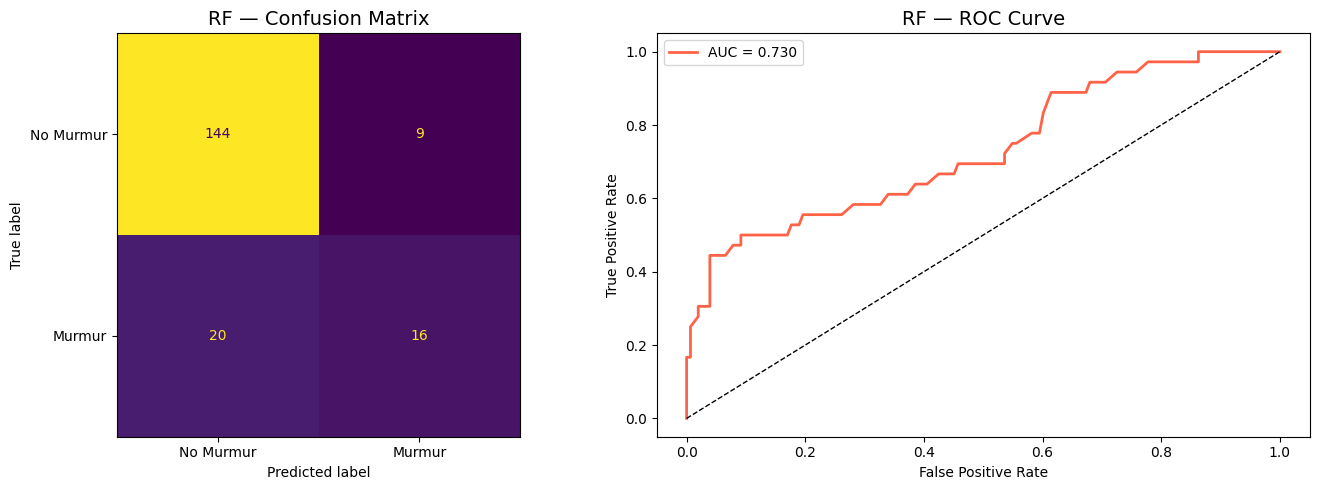

✅ Plot saved to rf_evaluation1.png


In [12]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, preds_rf)
ConfusionMatrixDisplay(cm, display_labels=['No Murmur', 'Murmur']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('RF — Confusion Matrix', fontsize=14)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, probs_rf)
axes[1].plot(fpr, tpr, color='tomato', lw=2, label=f'AUC = {auc_rf:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('RF — ROC Curve', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.savefig('rf_evaluation1.png', dpi=150)
plt.show()
print('✅ Plot saved to rf_evaluation1.png')

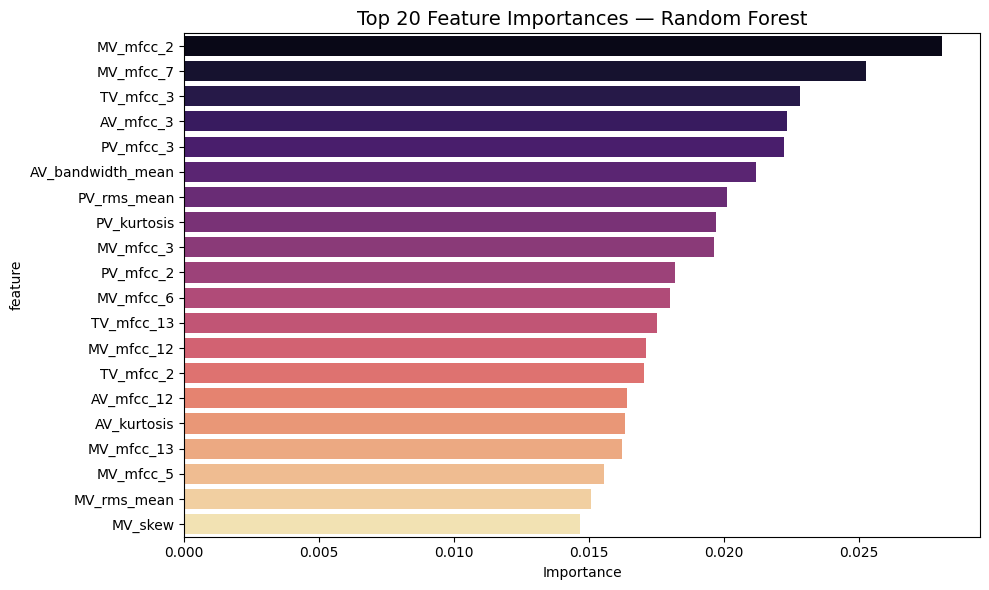

In [13]:
# ── Feature Importances (top 20) ──────────────────────────────────────────────
importances = rf_pipeline.named_steps['model'].feature_importances_
feat_names  = X.columns.tolist()

fi_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=fi_df, x='importance', y='feature', palette='magma')
plt.title('Top 20 Feature Importances — Random Forest', fontsize=14)
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('rf_feature_importance1.png', dpi=150)
plt.show()

In [14]:
# ── Save RF Model ─────────────────────────────────────────────────────────────
joblib.dump(rf_pipeline, 'murmur_model1.joblib')
print('✅ Random Forest model saved as murmur_model1.joblib')

✅ Random Forest model saved as murmur_model1.joblib


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the models with class balancing (AdaBoost doesn't support class_weight natively)
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42)
}

print("╔══════════════════════════════════════╗")
print("║  Additional Models Performance       ║")
print("╠══════════════════════════════════════╣")

# Assuming rf_pipeline from your notebook has a scaler, we'll scale the data first
X_train_scaled = rf_pipeline.named_steps['scaler'].transform(X_train)
X_test_scaled = rf_pipeline.named_steps['scaler'].transform(X_test)

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    # Predict
    y_pred = model.predict(X_test_scaled)
    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    
    print(f"║ {name.ljust(20)} │ Acc: {acc*100:.2f}%")
    print("╚══════════════════════════════════════╝")
    print(classification_report(y_test, y_pred, target_names=["No Murmur", "Murmur"]))
    print("\n")

╔══════════════════════════════════════╗
║  Additional Models Performance       ║
╠══════════════════════════════════════╣
║ Logistic Regression  │ Acc: 66.67%
╚══════════════════════════════════════╝
              precision    recall  f1-score   support

   No Murmur       0.88      0.69      0.77       153
      Murmur       0.30      0.58      0.40        36

    accuracy                           0.67       189
   macro avg       0.59      0.63      0.58       189
weighted avg       0.77      0.67      0.70       189



║ SVM (RBF)            │ Acc: 72.49%
╚══════════════════════════════════════╝
              precision    recall  f1-score   support

   No Murmur       0.87      0.78      0.82       153
      Murmur       0.35      0.50      0.41        36

    accuracy                           0.72       189
   macro avg       0.61      0.64      0.61       189
weighted avg       0.77      0.72      0.74       189



║ Decision Tree        │ Acc: 74.07%
╚═════════════════════════

---
## 🖼️ 6. Build Spectrogram Dataset (for CNN)

In [15]:
def build_spectrogram_dataset(csv_path, audio_path, n_mels=N_MELS, mel_time=MEL_TIME, sr=SR):
    """
    For each patient × recording location:
      1. Load audio
      2. Compute Mel spectrogram → power-to-dB
      3. Pad/crop to fixed shape (n_mels × mel_time)
      4. Normalize to [0, 1]
    Returns X (N, n_mels, mel_time), y (N,)
    """
    df_csv = pd.read_csv(csv_path)
    X_list, y_list = [], []

    for _, row in df_csv.iterrows():
        patient_id = row['Patient ID']
        locations  = row.get('Recording locations:', '')
        murmur     = row['Murmur']

        if pd.isna(locations):
            continue

        for loc in str(locations).split('+'):
            file_path = os.path.join(audio_path, f'{patient_id}_{loc.strip()}.wav')
            if not os.path.exists(file_path):
                continue

            audio, _ = librosa.load(file_path, sr=sr)
            mel      = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_mels)
            mel_db   = librosa.power_to_db(mel, ref=np.max)

            # Pad or crop to fixed width
            if mel_db.shape[1] < mel_time:
                mel_db = np.pad(mel_db, ((0, 0), (0, mel_time - mel_db.shape[1])))
            mel_db = mel_db[:, :mel_time]

            # Normalize
            dmin, dmax = mel_db.min(), mel_db.max()
            if dmax - dmin > 0:
                mel_db = (mel_db - dmin) / (dmax - dmin)

            X_list.append(mel_db)
            y_list.append(1 if murmur == 'Present' else 0)

    return np.array(X_list), np.array(y_list)


print('Building spectrogram dataset (this may take a few minutes)...')
X_spec, y_spec = build_spectrogram_dataset(CSV_PATH, AUDIO_PATH)

print(f'X shape : {X_spec.shape}  →  (samples, {N_MELS} mel-bands, {MEL_TIME} time-steps)')
print(f'y shape : {y_spec.shape}')
print(f'Class balance — Murmur: {y_spec.sum()}  |  No Murmur: {(y_spec == 0).sum()}')

Building spectrogram dataset (this may take a few minutes)...
X shape : (3120, 64, 128)  →  (samples, 64 mel-bands, 128 time-steps)
y shape : (3120,)
Class balance — Murmur: 606  |  No Murmur: 2514


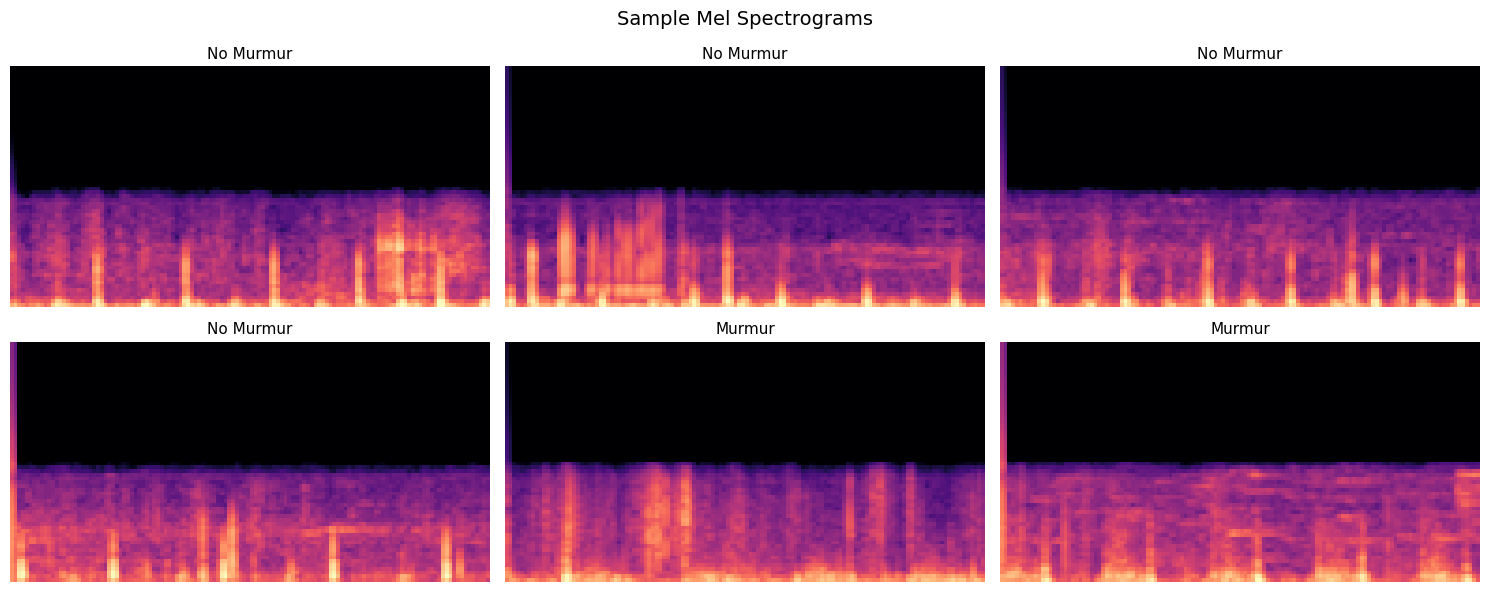

In [16]:
# ── Visualise a few spectrograms ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 6))

for i, ax in enumerate(axes.flatten()):
    if i >= len(X_spec): break
    ax.imshow(X_spec[i], aspect='auto', origin='lower', cmap='magma')
    ax.set_title(f'{"Murmur" if y_spec[i] == 1 else "No Murmur"}', fontsize=11)
    ax.axis('off')

plt.suptitle('Sample Mel Spectrograms', fontsize=14)
plt.tight_layout()
plt.show()

In [17]:
# ── Save spectrogram arrays ───────────────────────────────────────────────────
np.save('X_spectrogram1.npy', X_spec)
np.save('y_labels1.npy', y_spec)
print('✅ Spectrograms saved to X_spectrogram1.npy and y_labels1.npy')

✅ Spectrograms saved to X_spectrogram1.npy and y_labels1.npy


---
## 🧠 7. CNN Model — Build, Train, Evaluate, Save

In [18]:
# ── Load arrays (skip if already in memory) ───────────────────────────────────
X_cnn = np.load('X_spectrogram1.npy')
y_cnn = np.load('y_labels1.npy')

# Add channel dim → (N, 64, 128, 1)
X_cnn = X_cnn.reshape(X_cnn.shape[0], N_MELS, MEL_TIME, 1)

# One-hot encode labels
y_cat = to_categorical(y_cnn)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_cnn, y_cat, test_size=0.2, random_state=42, stratify=y_cnn
)

# Class weights for imbalanced data
cw = compute_class_weight('balanced', classes=np.unique(y_cnn), y=y_cnn)
class_weights = dict(enumerate(cw))

print(f'Train: {X_tr.shape[0]}  |  Test: {X_te.shape[0]}')
print(f'Class weights: {class_weights}')

Train: 2496  |  Test: 624
Class weights: {0: 0.6205250596658711, 1: 2.5742574257425743}


In [19]:
# ── CNN Architecture ──────────────────────────────────────────────────────────
def build_cnn(input_shape=(N_MELS, MEL_TIME, 1), num_classes=2):
    model = Sequential([
        Input(shape=input_shape),

        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),

        GlobalAveragePooling2D(),

        Dense(128, activation='relu'),
        Dropout(0.5),

        Dense(num_classes, activation='softmax')
    ], name='HeartMurmur_CNN')
    return model


cnn_model = build_cnn()
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

cnn_model.summary()

Model: "HeartMurmur_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 128, 32)         │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64, 128, 32)         │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 16, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 16, 128)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 8, 16, 256)          │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 8, 16, 256)          │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 422,914 (1.61 MB)

 Trainable params: 421,954 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [22]:
# ── Callbacks ─────────────────────────────────────────────────────────────────
os.makedirs('cnn_model', exist_ok=True)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('cnn_model/cnn_best_model1.keras', monitor='val_auc',
                    save_best_only=True, verbose=1)
]

# ── Train ─────────────────────────────────────────────────────────────────────
print('Training CNN...')
history = cnn_model.fit(
    X_tr, y_tr,
    validation_data=(X_te, y_te),
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks
)

Training CNN...
Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.5632 - auc: 0.5884 - loss: 0.6632
Epoch 1: val_auc improved from None to 0.81516, saving model to cnn_model/cnn_best_model1.keras

Epoch 1: finished saving model to cnn_model/cnn_best_model1.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 19s 193ms/step - accuracy: 0.6118 - auc: 0.6438 - loss: 0.6494 - val_accuracy: 0.8061 - val_auc: 0.8152 - val_loss: 0.5127 - learning_rate: 3.0000e-04
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.7008 - auc: 0.7509 - loss: 0.5819
Epoch 2: val_auc improved from 0.81516 to 0.82395, saving model to cnn_model/cnn_best_model1.keras

Epoch 2: finished saving model to cnn_model/cnn_best_model1.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 15s 187ms/step - accuracy: 0.6943 - auc: 0.7458 - loss: 0.5906 - val_accuracy: 0.8061 - val_auc: 0.8240 - val_loss: 0.5194 - learning_rate: 3.0000e-04
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.7367 - auc: 0.7913 - loss: 0.5631

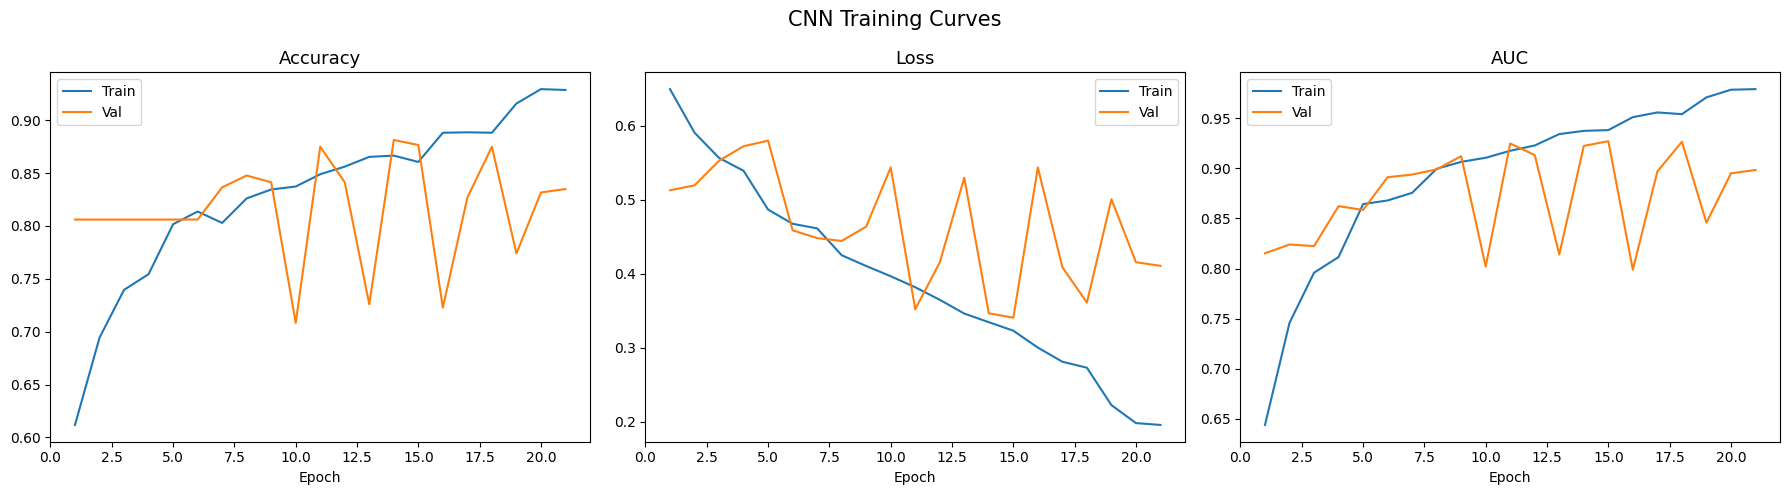

In [23]:
# ── Training Curves ───────────────────────────────────────────────────────────
hist = history.history
epochs_range = range(1, len(hist['accuracy']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy
axes[0].plot(epochs_range, hist['accuracy'],     label='Train')
axes[0].plot(epochs_range, hist['val_accuracy'], label='Val')
axes[0].set_title('Accuracy', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].legend()

# Loss
axes[1].plot(epochs_range, hist['loss'],     label='Train')
axes[1].plot(epochs_range, hist['val_loss'], label='Val')
axes[1].set_title('Loss', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].legend()

# AUC
axes[2].plot(epochs_range, hist['auc'],     label='Train')
axes[2].plot(epochs_range, hist['val_auc'], label='Val')
axes[2].set_title('AUC', fontsize=13)
axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.suptitle('CNN Training Curves', fontsize=15)
plt.tight_layout()
plt.savefig('cnn_training_curves1.png', dpi=150)
plt.show()

In [24]:
# ── CNN Evaluation ────────────────────────────────────────────────────────────
probs_cnn = cnn_model.predict(X_te, verbose=0)[:, 1]
preds_cnn = (probs_cnn >= 0.5).astype(int)
y_te_bin  = np.argmax(y_te, axis=1)       # back to binary labels

acc_cnn = accuracy_score(y_te_bin, preds_cnn)
auc_cnn = roc_auc_score(y_te_bin, probs_cnn)

print('=' * 50)
print('CNN Performance')
print('=' * 50)
print(f'Accuracy  : {acc_cnn:.4f}')
print(f'ROC-AUC   : {auc_cnn:.4f}')
print()
print(classification_report(y_te_bin, preds_cnn, target_names=['No Murmur', 'Murmur']))

CNN Performance
Accuracy  : 0.8766
ROC-AUC   : 0.8277

              precision    recall  f1-score   support

   No Murmur       0.88      0.98      0.93       503
      Murmur       0.82      0.46      0.59       121

    accuracy                           0.88       624
   macro avg       0.85      0.72      0.76       624
weighted avg       0.87      0.88      0.86       624



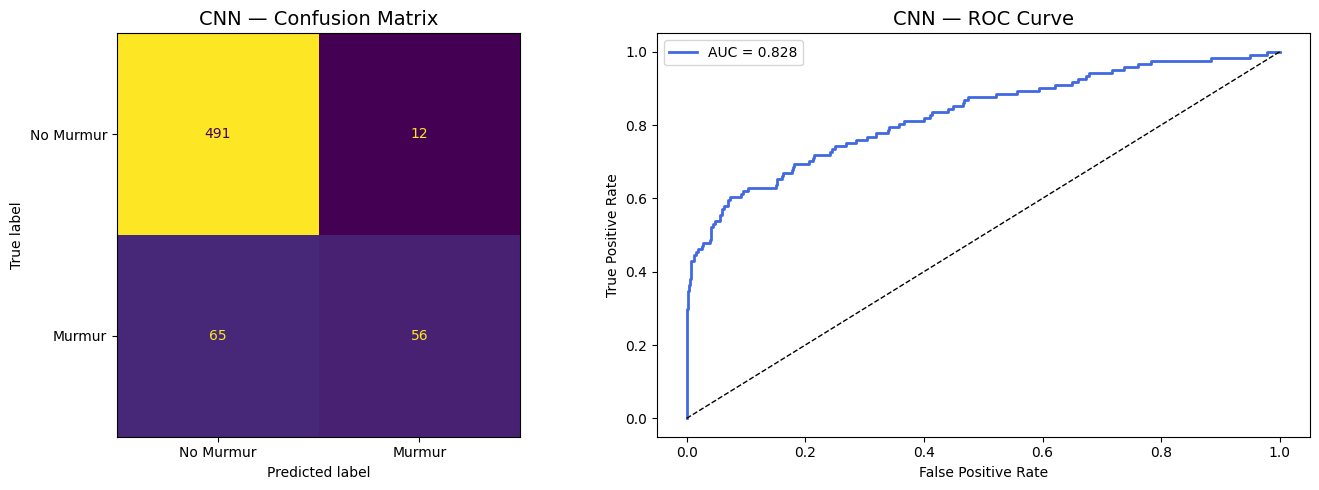

In [25]:
# ── CNN Confusion Matrix & ROC ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_cnn = confusion_matrix(y_te_bin, preds_cnn)
ConfusionMatrixDisplay(cm_cnn, display_labels=['No Murmur', 'Murmur']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('CNN — Confusion Matrix', fontsize=14)

fpr_c, tpr_c, _ = roc_curve(y_te_bin, probs_cnn)
axes[1].plot(fpr_c, tpr_c, color='royalblue', lw=2, label=f'AUC = {auc_cnn:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('CNN — ROC Curve', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.savefig('cnn_evaluation1.png', dpi=150)
plt.show()

In [26]:
# ── Side-by-side Model Comparison ─────────────────────────────────────────────
print('╔══════════════════════════════════════╗')
print('║       Model Performance Summary      ║')
print('╠══════════════════════════════════════╣')
print(f'║  Random Forest  │ Acc: {acc_rf*100:.2f}%  AUC: {auc_rf:.3f}  ║')
print(f'║  CNN            │ Acc: {acc_cnn*100:.2f}%  AUC: {auc_cnn:.3f}  ║')
print('╚══════════════════════════════════════╝')

╔══════════════════════════════════════╗
║       Model Performance Summary      ║
╠══════════════════════════════════════╣
║  Random Forest  │ Acc: 84.66%  AUC: 0.730  ║
║  CNN            │ Acc: 87.66%  AUC: 0.828  ║
╚══════════════════════════════════════╝


In [27]:
# ── Save CNN Model ────────────────────────────────────────────────────────────
cnn_model.save('cnn_model/cnn_best_model1.keras')
print('✅ CNN model saved to cnn_model/cnn_best_model.keras')
print()
print('📁 All outputs:')
print('  features.csv                     ← RF feature dataset')
print('  murmur_model.joblib              ← Trained RF model')
print('  X_spectrogram.npy / y_labels.npy ← CNN dataset')
print('  cnn_model/cnn_best_model.keras   ← Trained CNN model')
print('  rf_evaluation.png                ← RF confusion matrix + ROC')
print('  cnn_evaluation.png               ← CNN confusion matrix + ROC')
print('  cnn_training_curves.png          ← CNN training history')

✅ CNN model saved to cnn_model/cnn_best_model.keras

📁 All outputs:
  features.csv                     ← RF feature dataset
  murmur_model.joblib              ← Trained RF model
  X_spectrogram.npy / y_labels.npy ← CNN dataset
  cnn_model/cnn_best_model.keras   ← Trained CNN model
  rf_evaluation.png                ← RF confusion matrix + ROC
  cnn_evaluation.png               ← CNN confusion matrix + ROC
  cnn_training_curves.png          ← CNN training history


In [28]:
import os
print("Current Folder:", os.getcwd())
print("Files in this folder:", os.listdir())

Current Folder: C:\Users\Aditya
Files in this folder: ['-1.14-windows.xml', '.anaconda', '.android', '.arduinoIDE', '.bash_history', '.cache', '.conda', '.condarc', '.continuum', '.copilot', '.eclipse', '.gitconfig', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.lemminx', '.lesshst', '.m2', '.matplotlib', '.ms-ad', '.p2', '.SmartTomcat', '.spyder-py3', '.ssh', '.VirtualBox', '.vscode', 'Aditya - Shortcut (2).lnk', 'Aditya - Shortcut.lnk', 'anaconda3', 'app.py', 'AppData', 'Application Data', 'best_heart_murmur_model.pkl', 'circor-dataset-heart-murmur-detection.ipynb', 'cnn_evaluation.png', 'cnn_evaluation1.png', 'cnn_model', 'cnn_training_curves.png', 'cnn_training_curves1.png', 'confusion.jpg', 'Contacts', 'Cookies', 'dataset', 'Decision_tree_ensemble_lab_final (1).ipynb', 'Desktop', 'Documents', 'Downloads', 'eclipse', 'eclipse-workspace', 'eclipse-workspace1', 'eclipse-workspace2', 'eclipse-workspace3', 'eclipse-workspace4', 'efficientnetb0_cbam.h5', 'Favorites', 'fe8f88